In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv('Position_Salaries.csv')
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [30]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


Position    0
Level       0
Salary      0
dtype: int64

In [31]:
X = df.iloc[: , 1 :-1].values
Y = df.iloc[:, -1].values

In [32]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


training the polynomial regression model with the whole dataset

In [33]:
from sklearn.preprocessing import PolynomialFeatures

poly_reg = PolynomialFeatures(degree=4)
X_poly = poly_reg.fit_transform(X)

lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


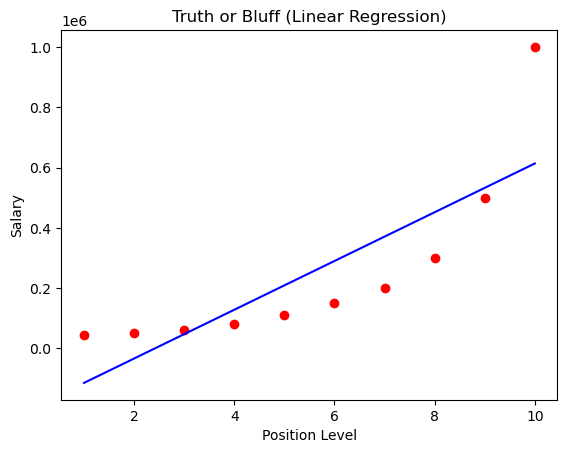

In [34]:
plt.scatter(X, Y, color='red')
plt.plot(X, lin_reg.predict(X), color='blue')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

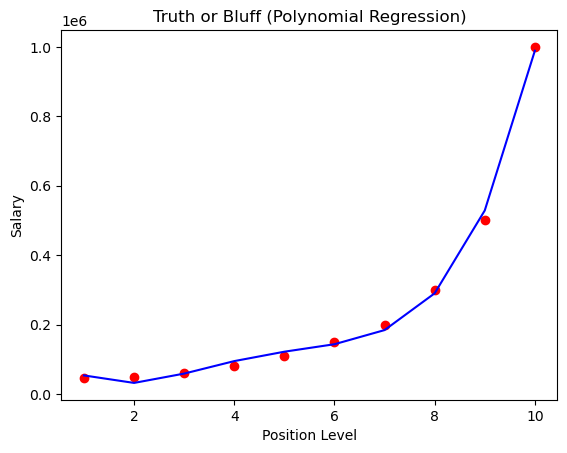

In [35]:
plt.scatter(X, Y, color='red')
plt.plot(X, lin_reg_2.predict(X_poly), color='blue')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

In [36]:
lin_reg.predict([[6.5]])

array([330378.78787879])

Predicting new results on polynomial regression model

In [37]:
poly_pred = lin_reg_2.predict(poly_reg.fit_transform([[6.5]]))
print('Polynomial Regression prediction:', poly_pred)

Polynomial Regression prediction: [158862.45265152]


Higher-resolution visualization for Polynomial Regression

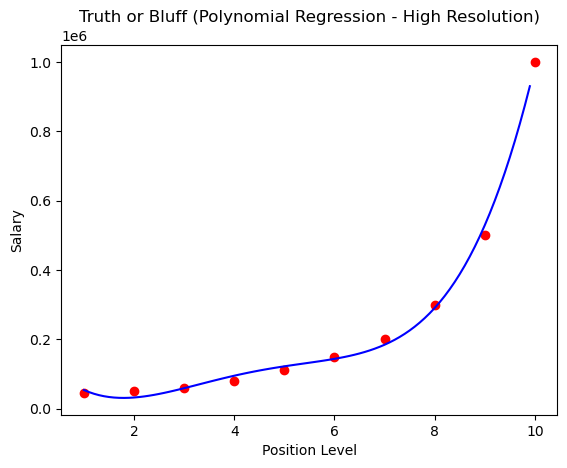

In [38]:
X_grid = np.arange(X.min(), X.max(), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))

plt.scatter(X, Y, color='red')
plt.plot(X_grid, lin_reg_2.predict(poly_reg.fit_transform(X_grid)), color='blue')
plt.title('Truth or Bluff (Polynomial Regression - High Resolution)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()